In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
DATA_DIR = Path("../Data/processed")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

..\Data\processed\train
..\Data\processed\val
..\Data\processed\test


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    transforms.RandomRotation(15),
    
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

In [8]:
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print("Number of classes:", len(train_dataset.classes))

Training images: 4320
Validation images: 540
Test images: 540
Number of classes: 90


In [9]:
for index, class_name in enumerate(train_dataset.classes):
    print(index, "→", class_name)

0 → antelope
1 → badger
2 → bat
3 → bear
4 → bee
5 → beetle
6 → bison
7 → boar
8 → butterfly
9 → cat
10 → caterpillar
11 → chimpanzee
12 → cockroach
13 → cow
14 → coyote
15 → crab
16 → crow
17 → deer
18 → dog
19 → dolphin
20 → donkey
21 → dragonfly
22 → duck
23 → eagle
24 → elephant
25 → flamingo
26 → fly
27 → fox
28 → goat
29 → goldfish
30 → goose
31 → gorilla
32 → grasshopper
33 → hamster
34 → hare
35 → hedgehog
36 → hippopotamus
37 → hornbill
38 → horse
39 → hummingbird
40 → hyena
41 → jellyfish
42 → kangaroo
43 → koala
44 → ladybugs
45 → leopard
46 → lion
47 → lizard
48 → lobster
49 → mosquito
50 → moth
51 → mouse
52 → octopus
53 → okapi
54 → orangutan
55 → otter
56 → owl
57 → ox
58 → oyster
59 → panda
60 → parrot
61 → pelecaniformes
62 → penguin
63 → pig
64 → pigeon
65 → porcupine
66 → possum
67 → raccoon
68 → rat
69 → reindeer
70 → rhinoceros
71 → sandpiper
72 → seahorse
73 → seal
74 → shark
75 → sheep
76 → snake
77 → sparrow
78 → squid
79 → squirrel
80 → starfish
81 → swan
82 → 

In [10]:
class_to_idx = train_dataset.class_to_idx

print(class_to_idx)

{'antelope': 0, 'badger': 1, 'bat': 2, 'bear': 3, 'bee': 4, 'beetle': 5, 'bison': 6, 'boar': 7, 'butterfly': 8, 'cat': 9, 'caterpillar': 10, 'chimpanzee': 11, 'cockroach': 12, 'cow': 13, 'coyote': 14, 'crab': 15, 'crow': 16, 'deer': 17, 'dog': 18, 'dolphin': 19, 'donkey': 20, 'dragonfly': 21, 'duck': 22, 'eagle': 23, 'elephant': 24, 'flamingo': 25, 'fly': 26, 'fox': 27, 'goat': 28, 'goldfish': 29, 'goose': 30, 'gorilla': 31, 'grasshopper': 32, 'hamster': 33, 'hare': 34, 'hedgehog': 35, 'hippopotamus': 36, 'hornbill': 37, 'horse': 38, 'hummingbird': 39, 'hyena': 40, 'jellyfish': 41, 'kangaroo': 42, 'koala': 43, 'ladybugs': 44, 'leopard': 45, 'lion': 46, 'lizard': 47, 'lobster': 48, 'mosquito': 49, 'moth': 50, 'mouse': 51, 'octopus': 52, 'okapi': 53, 'orangutan': 54, 'otter': 55, 'owl': 56, 'ox': 57, 'oyster': 58, 'panda': 59, 'parrot': 60, 'pelecaniformes': 61, 'penguin': 62, 'pig': 63, 'pigeon': 64, 'porcupine': 65, 'possum': 66, 'raccoon': 67, 'rat': 68, 'reindeer': 69, 'rhinoceros': 

In [11]:
BATCH_SIZE = 32

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [14]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


In [15]:
images = images.to(DEVICE)
labels = labels.to(DEVICE)

print("Images device:", images.device)
print("Labels device:", labels.device)

Images device: cuda:0
Labels device: cuda:0


In [16]:
if torch.cuda.is_available():
    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated() / 1024**2:.2f} MB"
    )
    
    print(
        f"GPU memory reserved: "
        f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB"
    )

GPU memory allocated: 18.38 MB
GPU memory reserved: 22.00 MB


In [17]:
def denormalize(image):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(image, 0, 1)

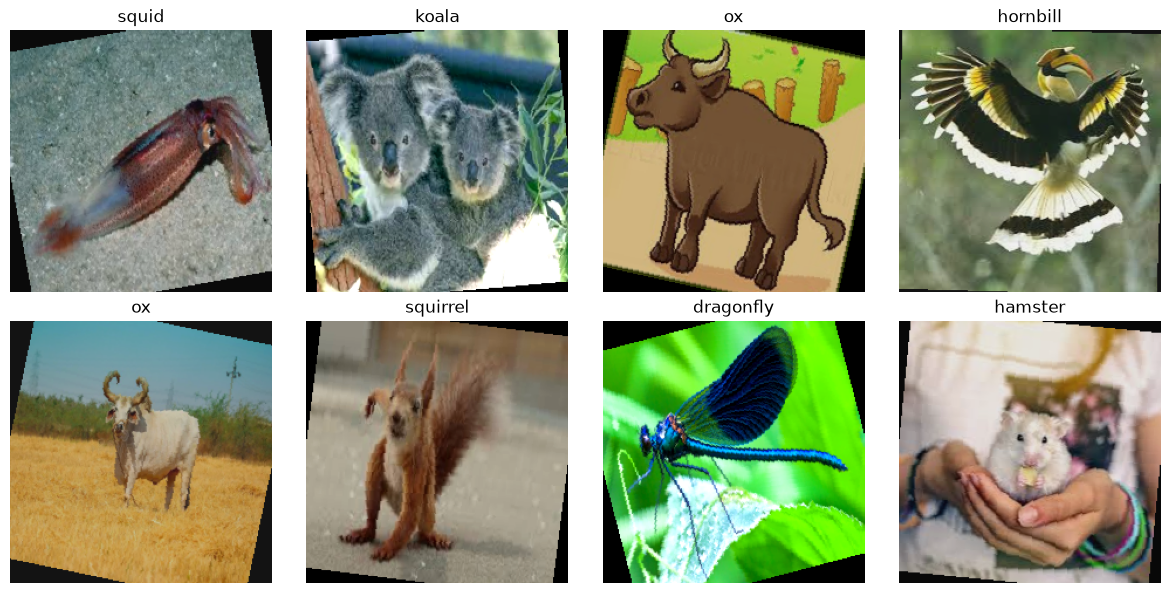

: 

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = denormalize(images[i])
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()